# 한국어 → 영어 번역기 만들기
## Attention 기반 Seq2Seq 모델

> **과제 목표**: Bahdanau Attention을 적용한 Seq2Seq 모델로 한국어 문장을 영어로 번역합니다.

---
### 전체 흐름
1. 라이브러리 버전 확인
2. 데이터 다운로드
3. 데이터 정제
4. 데이터 토큰화
5. 모델 설계 (Encoder / BahdanauAttention / Decoder)
6. 훈련
7. 번역 및 Attention Map 시각화


## Step 0. 라이브러리 버전 확인

In [ ]:
# ===================== Cell 1 =====================
import torch
print("CUDA 사용 가능:", torch.cuda.is_available())
print("MPS 사용 가능 :", torch.backends.mps.is_available())
if torch.cuda.is_available():
    print("GPU 이름:", torch.cuda.get_device_name(0))
elif torch.backends.mps.is_available():
    print("장치: Apple MPS (Metal Performance Shaders)")

In [ ]:
# ===================== Cell 2 =====================
import pandas
import torch
import matplotlib

print("pandas  :", pandas.__version__)
print("torch   :", torch.__version__)
print("matplotlib:", matplotlib.__version__)

## Step 0-2. 라이브러리 Import 및 환경 설정

In [ ]:
# ===================== Cell 3 =====================
import os
import re
import urllib.request
import tarfile

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset #DataLoader 데이터를 batch 단위로 자동 공급
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# python-mecab-ko 설치 필요: pip install python-mecab-ko
from mecab import MeCab

# 장치 설정: MPS(Apple Silicon) > CUDA > CPU 순으로 선택
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"사용 장치: {device}")

# 한글 폰트 설정 (Mac: AppleGothic)
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지
print("환경 설정 완료!")

## Step 1. 데이터 다운로드

`jungyeul/korean-parallel-corpora` 에서 한영 병렬 데이터를 다운로드합니다.

- 파일: `korean-english-park.train.tar.gz`
- 내용: 한국어-영어 병렬 문장 쌍


In [ ]:
# ===================== Cell 4 =====================
# 데이터 저장 경로 설정
base_dir = "/Users/macminim4/DLthon/febDLthon"
dataset_dir = os.path.join(base_dir, "datasets", "kor-eng")
os.makedirs(dataset_dir, exist_ok=True)

tar_path = os.path.join(dataset_dir, "korean-english-park.train.tar.gz")

if not os.path.exists(tar_path):
    print("데이터 다운로드 중...")
    url = "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz"
    urllib.request.urlretrieve(url, tar_path)
    print("다운로드 완료!")
else:
    print("이미 다운로드됨. 스킵.")

extract_dir = os.path.join(dataset_dir, "extracted")
if not os.path.exists(extract_dir):
    print("압축 해제 중...")
    os.makedirs(extract_dir, exist_ok=True)
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(extract_dir)
    print("압축 해제 완료!")
else:
    print("이미 압축 해제됨. 스킵.")

print("파일 목록:", os.listdir(extract_dir))

In [ ]:
# ===================== Cell 5 =====================
# 한국어 파일, 영어 파일 경로 탐색
kor_file = None
eng_file = None

for root, dirs, files in os.walk(extract_dir):
    for f in files:
        if f.endswith(".ko"):
            kor_file = os.path.join(root, f)
        elif f.endswith(".en"):
            eng_file = os.path.join(root, f)

print("한국어 파일:", kor_file)
print("영어 파일 :", eng_file)

In [ ]:
# ===================== Cell 6 =====================
# 파일 읽기
with open(kor_file, "r", encoding="utf-8") as f:
    kor_lines = f.read().strip().split("\n")

with open(eng_file, "r", encoding="utf-8") as f:
    eng_lines = f.read().strip().split("\n")

print(f"한국어 문장 수: {len(kor_lines)}")
print(f"영어 문장 수 : {len(eng_lines)}")
print()
print("예시 (한국어):", kor_lines[0])
print("예시 (영어)  :", eng_lines[0])

## Step 2. 데이터 정제

### 주요 작업
1. **중복 제거**: `set` 자료형의 중복 불허 특성 활용
2. **전처리 함수 정의**: 영어/한국어 각각 적용
3. **토큰 추가**: 영어 문장에 `<start>`, `<end>` 토큰 추가
4. **길이 필터링**: 토큰 길이 40 이하인 데이터만 선별


In [ ]:
# ===================== Cell 7 =====================
# ── 중복 제거 ──────────────────────────────────────────────────────
pairs = list(set(zip(kor_lines, eng_lines)))

print(f"중복 제거 전: {len(kor_lines)}")
print(f"중복 제거 후: {len(pairs)}")

In [ ]:
# ===================== Cell 8 =====================
# ── 전처리 함수 정의 ──────────────────────────────────────────────
def preprocess_eng(sentence):
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)
    sentence = sentence.strip()
    return sentence

def preprocess_kor(sentence):
    sentence = sentence.strip()
    sentence = re.sub(r"[^가-힣0-9?.!,\s]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence)
    sentence = sentence.strip()
    return sentence

print(preprocess_eng("Hello, World! How are you?"))
print(preprocess_kor("오바마는 대통령이다."))

In [ ]:
# ===================== Cell 9 =====================
# ── 전처리 적용 및 데이터프레임 구성 ──────────────────────────────
kor_corpus = []
eng_corpus = []

for kor, eng in pairs:
    k = preprocess_kor(kor)
    e = preprocess_eng(eng)
    if k and e:
        kor_corpus.append(k)
        eng_corpus.append(e)

df = pd.DataFrame({"kor": kor_corpus, "eng": eng_corpus})
print(f"전처리 후 데이터 수: {len(df)}")
df.head()

In [ ]:
# ===================== Cell 10 =====================
# ── MeCab 토크나이저 초기화 & 길이 필터링 ────────────────────────
mecab = MeCab()

def get_kor_tokens(sentence):
    return mecab.morphs(sentence)

def get_eng_tokens(sentence):
    return sentence.split()

filtered = []
for _, row in df.iterrows():
    kor_tokens = get_kor_tokens(row["kor"])
    eng_tokens = get_eng_tokens(row["eng"])
    if len(kor_tokens) <= 40 and len(eng_tokens) <= 40:
        filtered.append({"kor": row["kor"], "eng": row["eng"]})

df = pd.DataFrame(filtered).reset_index(drop=True)
print(f"길이 필터링 후 데이터 수: {len(df)}")
df.head()

## Step 3. 데이터 토큰화

### 토큰화 방식
- **영어**: `split()` 함수 사용 + `<start>` / `<end>` 토큰 추가
- **한국어**: KoNLPy의 MeCab 형태소 분석기 사용

### 특수 토큰
| 토큰 | ID | 역할 |
|------|----|------|
| `<pad>` | 0 | 패딩 |
| `<start>` | 1 | 문장 시작 |
| `<end>` | 2 | 문장 종료 |
| `<unk>` | 3 | 미등록 단어 |


In [ ]:
# ===================== Cell 11 =====================
# ── 단어장(Vocabulary) 구축 함수 ─────────────────────────────────
def build_vocab(token_lists, min_freq=1):
    word2idx = {"<pad>": 0, "<start>": 1, "<end>": 2, "<unk>": 3}
    idx2word = {0: "<pad>", 1: "<start>", 2: "<end>", 3: "<unk>"}

    from collections import Counter
    counter = Counter()
    for tokens in token_lists:
        counter.update(tokens)

    for word, freq in counter.items():
        if freq >= min_freq and word not in word2idx:
            idx = len(word2idx)
            word2idx[word] = idx
            idx2word[idx] = word

    return word2idx, idx2word

print("단어장 구축 함수 정의 완료!")

In [ ]:
# ===================== Cell 12 =====================
# ── 토큰화 수행 ───────────────────────────────────────────────────
kor_token_lists = [mecab.morphs(sent) for sent in df["kor"]]
eng_token_lists = [["<start>"] + sent.split() + ["<end>"] for sent in df["eng"]]

kor_word2idx, kor_idx2word = build_vocab(kor_token_lists, min_freq=1)
eng_word2idx, eng_idx2word = build_vocab(eng_token_lists, min_freq=1)

print(f"한국어 단어장 크기: {len(kor_word2idx)}")
print(f"영어 단어장 크기 : {len(eng_word2idx)}")
print()
print("한국어 토큰 예시:", kor_token_lists[0])
print("영어 토큰 예시  :", eng_token_lists[0])

In [ ]:
# ===================== Cell 13 =====================
# ── Dataset 클래스 정의 ───────────────────────────────────────────
MAX_LEN = 40
BATCH_SIZE = 64
PAD_ID = 0
BOS_ID = 1
EOS_ID = 2
UNK_ID = 3

class KorEngDataset(Dataset):
    def __init__(self, df, kor_word2idx, eng_word2idx, max_len):
        self.df = df.reset_index(drop=True)
        self.kor_word2idx = kor_word2idx
        self.eng_word2idx = eng_word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        kor_sent = self.df.iloc[idx]["kor"]
        eng_sent = self.df.iloc[idx]["eng"]

        kor_tokens = mecab.morphs(kor_sent)
        src_ids = [self.kor_word2idx.get(t, UNK_ID) for t in kor_tokens]
        src_ids = src_ids[:self.max_len]
        src_ids += [PAD_ID] * (self.max_len - len(src_ids))

        eng_tokens = eng_sent.split()
        eng_ids = [self.eng_word2idx.get(t, UNK_ID) for t in eng_tokens]

        trg_input = [BOS_ID] + eng_ids[:self.max_len - 2] + [EOS_ID]
        trg_label = eng_ids[:self.max_len - 1] + [EOS_ID]

        trg_input += [PAD_ID] * (self.max_len - len(trg_input))
        trg_label += [PAD_ID] * (self.max_len - len(trg_label))

        return (torch.tensor(src_ids),
                torch.tensor(trg_input),
                torch.tensor(trg_label))

print("KorEngDataset 클래스 정의 완료!")

In [ ]:
# ===================== Cell 14 =====================
# ── DataLoader 생성 ───────────────────────────────────────────────
dataset = KorEngDataset(df, kor_word2idx, eng_word2idx, max_len=MAX_LEN)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

for src, trg_input, trg_label in train_loader:
    print("src shape      :", src.shape)
    print("trg_input shape:", trg_input.shape)
    print("trg_label shape:", trg_label.shape)
    break

## Step 4. 모델 설계

`seq2seq_attention_local.ipynb` 의 모델 구조를 그대로 사용합니다.

### 모델 구성
```
BahdanauAttention  ← Encoder hidden state + Decoder hidden state → 가중치 계산
Encoder (GRU)      ← 한국어 입력 → 모든 time-step hidden state 출력
Decoder (GRU)      ← Attention context + 이전 단어 → 다음 영어 단어 예측
Seq2SeqAttention   ← Encoder + Decoder 통합
```


In [ ]:
# ===================== Cell 15 =====================
# ── BahdanauAttention ─────────────────────────────────────────────
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        src_len = encoder_outputs.shape[0]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))
        attention = self.v(energy).squeeze(2)
        return nn.functional.softmax(attention, dim=1)

print("BahdanauAttention 정의 완료!")

In [ ]:
# ===================== Cell 16 =====================
# ── Encoder ───────────────────────────────────────────────────────
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=PAD_ID)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

print("Encoder 정의 완료!")

In [ ]:
# ===================== Cell 17 =====================
# ── Decoder ───────────────────────────────────────────────────────
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super().__init__()
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_ID)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        input = input.unsqueeze(0)# 차원 추가
        embedded = self.embedding(input)
        a = self.attention(hidden[-1], encoder_outputs)
        a = a.unsqueeze(1)
        enc = encoder_outputs.permute(1, 0, 2)
        context = torch.bmm(a, enc).permute(1, 0, 2)
        output, hidden = self.rnn(embedded, hidden)
        output  = output.squeeze(0)
        context = context.squeeze(0)
        prediction = self.fc_out(torch.cat((output, context), dim=1))
        return prediction, hidden, a.squeeze(1)

print("Decoder 정의 완료!")

In [ ]:
# ===================== Cell 18 =====================
# ── Seq2SeqAttention (전체 모델) ──────────────────────────────────
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, trg=None, max_len=40, bos_id=BOS_ID, eos_id=EOS_ID):
        batch_size = src.shape[1]
        outputs    = []
        attentions = []

        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(trg.shape[0]):
                output, hidden, attention = self.decoder(trg[t], hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
        else:
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)
            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs    = torch.cat(outputs, dim=0)
        attentions = torch.cat(attentions, dim=0)
        return outputs, attentions

print("Seq2SeqAttention 정의 완료!")

In [ ]:
# ===================== Cell 19 =====================
# ── 모델 인스턴스 생성 ────────────────────────────────────────────
INPUT_DIM  = len(kor_word2idx)
OUTPUT_DIM = len(eng_word2idx)
EMB_DIM    = 256
HID_DIM    = 512

attention = BahdanauAttention(HID_DIM).to(device)
encoder   = Encoder(INPUT_DIM, EMB_DIM, HID_DIM).to(device)
decoder   = Decoder(OUTPUT_DIM, EMB_DIM, HID_DIM, attention).to(device)
model     = Seq2SeqAttention(encoder, decoder, device).to(device)

print(model)
print(f"\n총 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

## Step 5. 훈련

### 훈련 설정
- **Optimizer**: Adam (lr=1e-3)
- **Loss**: CrossEntropyLoss (`<pad>` 토큰 무시)
- **Gradient Clipping**: max_norm=1 (기울기 폭발 방지)

> 과제 조건: `eval_step()` 없음 (훈련 데이터 = 전체 데이터)


In [ ]:
# ===================== Cell 20 =====================
# ── Optimizer & Loss ──────────────────────────────────────────────
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

print("Optimizer: Adam (lr=1e-3)")
print("Loss     : CrossEntropyLoss (ignore_index=PAD)")

In [ ]:
# ===================== Cell 21 =====================
# ── train_step 함수 ───────────────────────────────────────────────
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0
    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        src       = src.T.to(device)
        trg_input = trg_input.T.to(device)
        trg_label = trg_label.to(device)

        optimizer.zero_grad()

        outputs, _ = model(src, trg_input)

        # ※ 둘 다 batch 우선으로 flatten 해야 쌍이 올바르게 맞아요
        outputs   = outputs.permute(1, 0, 2).contiguous().view(-1, outputs.shape[-1])
        trg_label = trg_label.view(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    return epoch_loss / len(data_loader)

print("train_step 함수 정의 완료!")

In [ ]:
# ===================== Cell 22 =====================
# ── 훈련 시작 ─────────────────────────────────────────────────────
EPOCHS = 20
train_losses = []

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    train_losses.append(train_loss)
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Train Loss: {train_loss:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

## Step 6. 번역 및 Attention Map 시각화

훈련된 모델로 한국어 문장을 영어로 번역하고,
Attention Map으로 모델이 어떤 단어에 집중했는지 확인합니다.


In [ ]:
# ===================== Cell 23 =====================
# ── evaluate 함수 ─────────────────────────────────────────────────
def evaluate(sentence, model, kor_word2idx, eng_idx2word, max_len=40):
    model.eval()

    sentence = preprocess_kor(sentence)
    tokens = mecab.morphs(sentence)
    src_ids = [kor_word2idx.get(t, UNK_ID) for t in tokens]
    src_ids = src_ids[:max_len]
    src_ids += [PAD_ID] * (max_len - len(src_ids))

    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    predicted_ids = outputs.argmax(2).squeeze(1).cpu().numpy()
    result = []
    for idx in predicted_ids:
        word = eng_idx2word.get(idx, "<unk>")
        if word == "<end>":
            break
        if word not in ("<start>", "<pad>"):
            result.append(word)

    return result, tokens, attentions.squeeze(1).cpu().numpy()

print("evaluate 함수 정의 완료!")

In [ ]:
# ===================== Cell 24 =====================
# ── Attention Map 시각화 & translate 함수 ────────────────────────
def plot_attention(attention, src_tokens, trg_tokens):
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.matshow(attention[:len(trg_tokens), :len(src_tokens)], cmap="viridis")
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, rotation=90, fontsize=11)
    ax.set_yticks(range(len(trg_tokens)))
    ax.set_yticklabels(trg_tokens, fontsize=11)
    ax.set_xlabel("한국어 입력 (Input)")
    ax.set_ylabel("영어 출력 (Output)")
    ax.set_title("Attention Map")
    plt.tight_layout()
    plt.show()

def translate(sentence):
    result, src_tokens, attention = evaluate(
        sentence, model, kor_word2idx, eng_idx2word, max_len=MAX_LEN
    )
    print(f"입력 (KOR): {sentence}")
    print(f"번역 (ENG): {' '.join(result)}")
    print()
    if result:
        plot_attention(attention, src_tokens, result)
    return result

print("translate / plot_attention 함수 정의 완료!")

## Step 7. 과제 예문 번역

> 아래 4개 예문을 번역하고 Attention Map을 시각화합니다.


K1)
입력 (KOR): 오바마는 대통령이다.
번역 (ENG): the president went to the president .



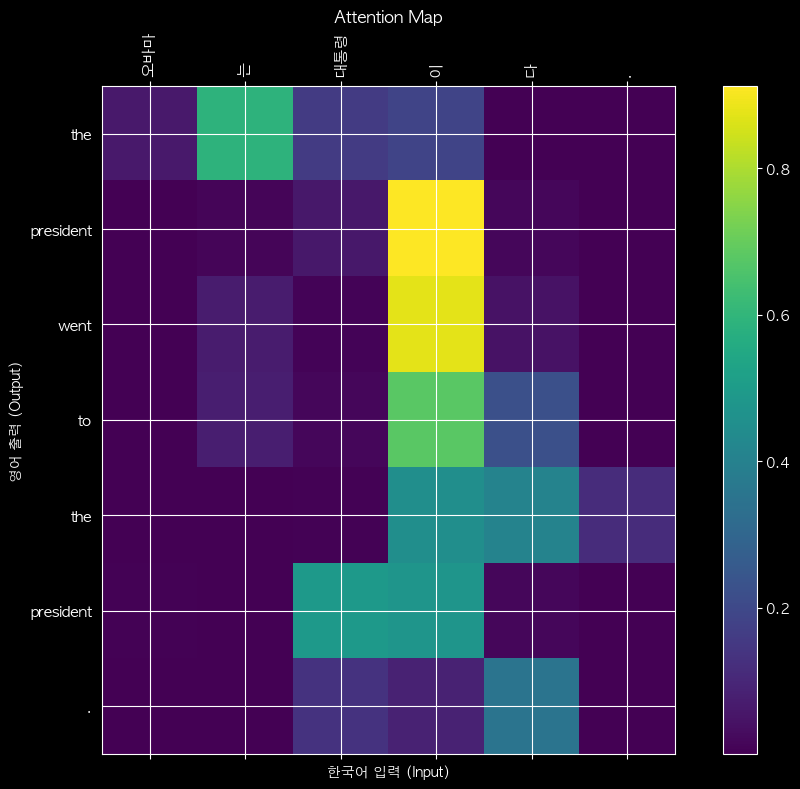


K2)
입력 (KOR): 시민들은 도시 속에 산다.
번역 (ENG): citizens in town , public market is .



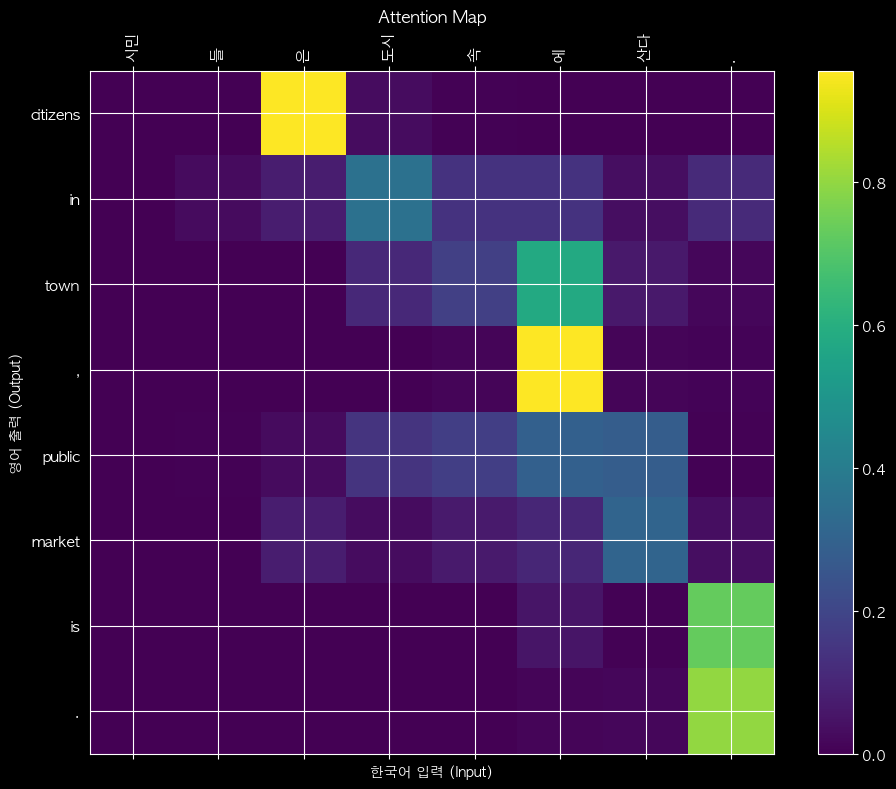


K3)
입력 (KOR): 커피는 필요 없다.
번역 (ENG): which need to do necessary to find necessary .



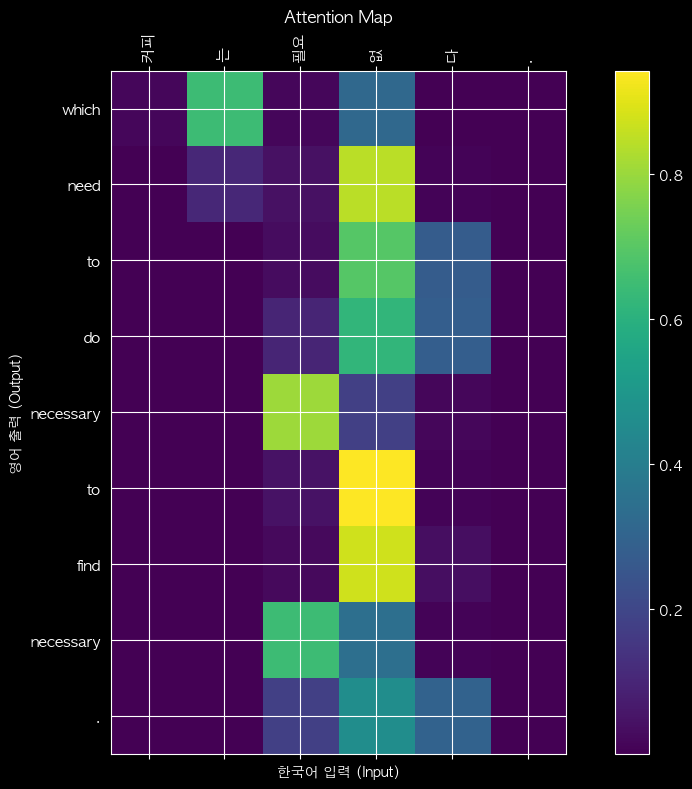


K4)
입력 (KOR): 일곱 명의 사망자가 발생했다.
번역 (ENG): seven of those killed were wounded during last night s six



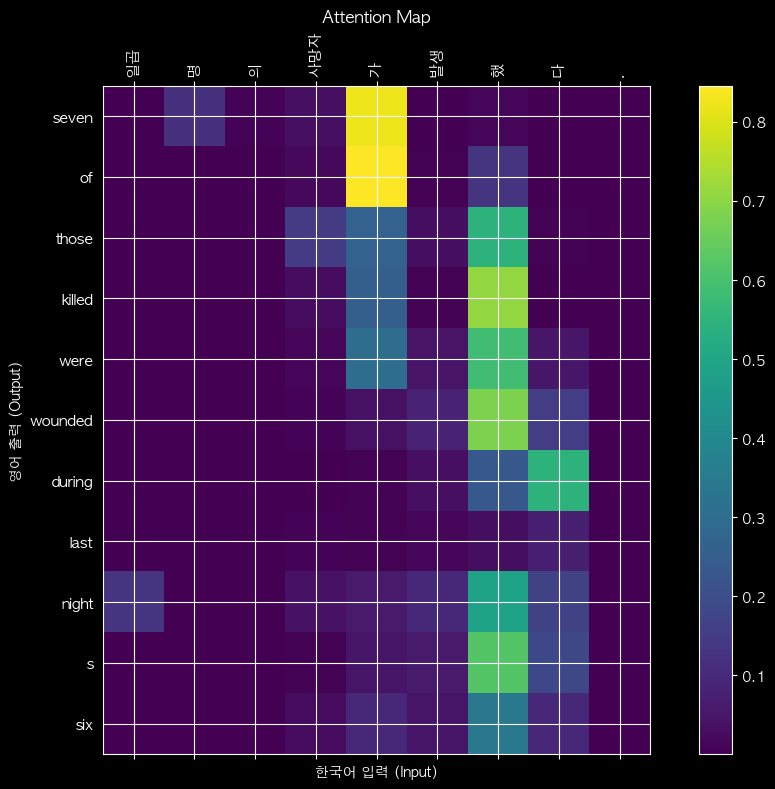

In [53]:
# ===================== Cell 25 =====================
# ── 과제 예문 번역 ────────────────────────────────────────────────
test_sentences = [
    "오바마는 대통령이다.",       # K1
    "시민들은 도시 속에 산다.",   # K2
    "커피는 필요 없다.",          # K3
    "일곱 명의 사망자가 발생했다." # K4
]

results = {}
for i, sent in enumerate(test_sentences, 1):
    print(f"{'='*50}")
    print(f"K{i})")
    result = translate(sent)
    results[f"K{i}"] = ' '.join(result) + ' <end>'
    print()

In [54]:
# ===================== Cell 26 =====================
# ── 최종 제출 결과 출력 ───────────────────────────────────────────
print("=" * 50)
print("최종 번역 결과 (제출용)")
print("=" * 50)
for k, v in results.items():
    print(f"{k}) {v}")

최종 번역 결과 (제출용)
K1) the president went to the president . <end>
K2) citizens in town , public market is . <end>
K3) which need to do necessary to find necessary . <end>
K4) seven of those killed were wounded during last night s six <end>
